In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
from dotenv import load_dotenv
import operator

In [2]:

load_dotenv()

True

In [3]:
class FeedbackStruct(BaseModel):
    feedback : str=Field(description='Detailed feedback for the essay')
    score : int=Field(description='Score out of 10',ge=0,le=10)
    


In [4]:
model=ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0.7,
    max_tokens=2000
)

In [5]:
struct_model=model.with_structured_output(FeedbackStruct)

In [6]:
class UPSCstate(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_score:Annotated[list[int],operator.add]
    average_score:float

In [7]:
def evaluate_language(state: UPSCstate):
    prompt=f''' Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n  {state['essay']}'''
    ans=struct_model.invoke(prompt)

    return {
        'language_feedback':ans.feedback,
        'individual_score':[ans.score]
    }

In [8]:
def evaluate_depth(state: UPSCstate):
    prompt=f''' Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n  {state['essay']}'''
    ans=struct_model.invoke(prompt)

    return {
        'analysis_feedback':ans.feedback,
        'individual_score':[ans.score]
    }

In [9]:
def evaluate_clarity(state: UPSCstate):
    prompt=f''' Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n  {state['essay']}'''
    ans=struct_model.invoke(prompt)

    return {
        'clarity_feedback':ans.feedback,
        'individual_score':[ans.score]
    }

In [10]:
def summary(state: UPSCstate):
     prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
     overall_feedback = model.invoke(prompt).content

    # avg calculate
     avg_score = sum(state['individual_score'])/len(state['individual_score'])

     return {'overall_feedback': overall_feedback, 'average_score': avg_score}

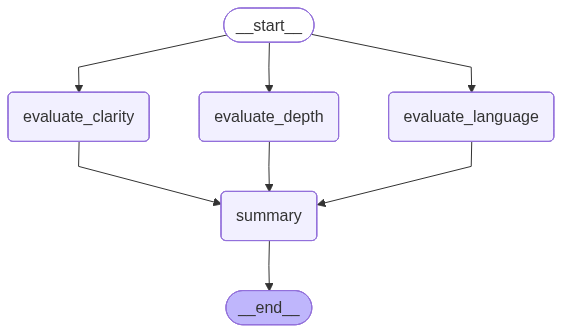

In [11]:
graph=StateGraph(UPSCstate)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_depth',evaluate_depth)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('summary',summary)


graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_depth')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','summary')
graph.add_edge('evaluate_depth','summary')
graph.add_edge('evaluate_clarity','summary')

graph.add_edge('summary',END)

workflow=graph.compile()
workflow



In [12]:
initial_out={
    'essay':'''The lyrics of the song “Dandelion” portray a deeply emotional and passionate expression of love, vulnerability, and devotion. Through soft yet intense imagery, the speaker presents herself as someone genuine in a world filled with superficial relationships. The recurring line, “Mean what I say, say what I mean,” immediately establishes honesty as the foundation of her feelings. Unlike “other boys” or “other flowers,” the speaker believes her connection is unique, sincere, and emotionally meaningful.

One of the strongest themes in the lyrics is commitment and emotional availability. The singer repeatedly reassures her lover that she is serious about the relationship, despite acknowledging that her words may initially sound playful or unreal. Phrases like “I give my word” and “I promise” reinforce trust and loyalty, suggesting that she wants to be seen as dependable and authentic. The desire for the other person to “stay” reflects fear of losing a valuable connection while also revealing emotional vulnerability.

The metaphor of the “dandelion” plays a central role in the song. Traditionally, dandelions symbolize wishes, resilience, and delicate beauty. By calling herself a dandelion, the speaker presents herself as both soft and emotionally open, yet capable of surviving despite uncertainty. The line “Can’t you see I bloom at night?” suggests hidden beauty and emotional depth that reveal themselves only in intimacy and trust. It also creates a dreamy, almost magical atmosphere throughout the song.

Another important aspect of the lyrics is desire and intimacy. The imagery of “plant this seed” symbolizes nurturing a relationship and allowing love to grow. At the same time, lines such as “I’m here on my knees” and “let’s get dirty” introduce sensual undertones, blending emotional closeness with physical attraction. However, the song focuses more on emotional honesty than purely physical desire. The singer wants to be chosen not just for attraction, but for the sincerity of her love and dedication.

Overall, the song expresses longing, passion, honesty, and emotional devotion through poetic symbolism and intimate language. Its soft, repetitive structure gives it a hypnotic and heartfelt tone, making it feel both romantic and vulnerable. The speaker’s message is clear: she wants genuine love, and she is willing to offer her whole self in return. '''

}
result=workflow.invoke(initial_out)
print(result)

{'essay': 'The lyrics of the song “Dandelion” portray a deeply emotional and passionate expression of love, vulnerability, and devotion. Through soft yet intense imagery, the speaker presents herself as someone genuine in a world filled with superficial relationships. The recurring line, “Mean what I say, say what I mean,” immediately establishes honesty as the foundation of her feelings. Unlike “other boys” or “other flowers,” the speaker believes her connection is unique, sincere, and emotionally meaningful.\n\nOne of the strongest themes in the lyrics is commitment and emotional availability. The singer repeatedly reassures her lover that she is serious about the relationship, despite acknowledging that her words may initially sound playful or unreal. Phrases like “I give my word” and “I promise” reinforce trust and loyalty, suggesting that she wants to be seen as dependable and authentic. The desire for the other person to “stay” reflects fear of losing a valuable connection while 